In [1]:
%env NU_SKYMAP_DIR=/data/user/azegarelli/IceCat-2-final/dataverse_files/fits/
import sys
sys.path.append("/data/user/gsommani/alertstack3.12/lib/python3.12/site-packages/")

env: NU_SKYMAP_DIR=/data/user/azegarelli/IceCat-2-final/dataverse_files/fits/


In [2]:
%env NU_SKYMAP_DIR=/data/user/azegarelli/IceCat-2-test/icecat_2/output/gcd_pass2/scans/probability_maps/
import sys
sys.path.append("/home/gsommani/alertstack3.12/lib/python3.12/site-packages/")
from alertstack.scramble_catalogues.sjoert_catalogue import (
    AccretionFlaresSjoertCatalogue, StrengthFluxWeightHypothesis
)
from examples.sjoert_accretion_flares_neutrino_alert import (
    sjoert_accretion_flares_analysis, plot_ts
)
from examples.flaires_neutrino_alert import (
    flaires_analysis, plot_ts
)
import numpy as np
from alertstack.stats import GammaDistribution
import matplotlib.pyplot as plt
from scipy.optimize import bisect
from scipy import interpolate

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 524 sources in total


In [3]:
!python --version

Python 3.12.8


In [12]:
all_res = flaires_analysis.load_results(
    filename="../../../../alertstack_results/flaires_n2000000_f0.07_s10_update_signalness.pkl"
)
sens_threshold = dict()
disc_3_threshold = dict()
disc_5_threshold = dict()
for key, val in all_res[0.].items():
    sens_threshold[key] = np.median(val)
    prob_3s = 1.35e-3
    prob_5s = 2.87e-7
    decreasing_vals = np.flip(np.sort(val))
    done_3s = False
    done_5s = False
    if len(val) <= int(1./prob_3s):
        print("Not enough scrambles for evaluating a 3 and 5 sigma level")
        disc_3_threshold[key] = decreasing_vals[0]
        disc_5_threshold[key] = decreasing_vals[0]
        done_3s = True
        done_5s = True
    if len(val) <= int(1./prob_5s):
        print("Not enough scrambles for evaluating a 5 sigma level")
        disc_5_threshold[key] = decreasing_vals[0]
        done_5s = True

    for i, v in enumerate(decreasing_vals):
        prob = (i + 1) / len(val)
        if prob >= prob_3s and not done_3s:
            disc_3_threshold[key] = v
            done_3s = True
        if prob >= prob_5s and not done_5s:
            disc_5_threshold[key] = v
            done_5s = True

In [13]:
1/len(val)

5e-08

In [14]:
def plot_ts(val, sens, disc_3, disc_5, filename='ts_bkg.png', density=True, bins=30):
    # plot TS + gamma distribution + sensitivity and disc potential
    data = np.array(val)
    # logbins = np.logspace(np.log10(2), np.log10(np.max(data)), 50)
    logbins = bins
    counts, bins_pos, _ = plt.hist(data, density=density, bins=logbins, alpha=0.)
    bins_centers = (bins_pos[:-1] + bins_pos[1:])/2.
    bins_widths = (bins_pos[1:] - bins_pos[:-1])/2.
    if density:
        errs = np.sqrt(counts*len(val))/len(val)
    else:
        errs = np.sqrt(counts)
    x_range = np.logspace(np.log10(min(data[data>0.])), np.log10(max(data)), 100)
    plt.errorbar(bins_centers, counts, errs, bins_widths, linestyle="", color="black")
    ylim = plt.gca().get_ylim() 
    plt.xlabel('TS')
    plt.yscale('log')
    #plt.xscale('log')
    plt.axvline(sens, color = 'tab:orange', ls='--', label='Sensitivity')
    plt.axvline(disc_3, color = 'tab:orange', ls='-.', label='3sigma disc')
    plt.axvline(disc_5, color = 'tab:orange', ls='dotted', label='5sigma disc')
    #plt.axvline(disc_5, color = 'tab:orange', ls=':', label='5sigma disc')
    plt.legend()

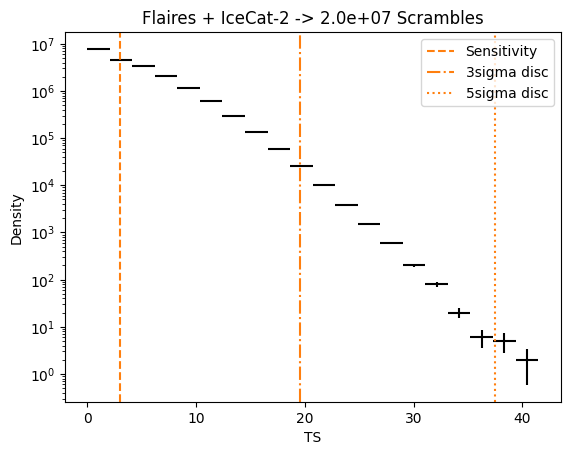

In [15]:
plot_ts(
    val,
    sens_threshold[key],
    disc_3_threshold[key],
    disc_5_threshold[key],
    filename="attempt_plot.png",
    density=False,
    bins=20
)

x = np.linspace(20,80,100)
plt.plot(x, np.exp(-0.2*x))

#plt.yscale('linear')
plt.ylabel("Density")
plt.title(f"Flaires + IceCat-2 -> {len(val):.1e} Scrambles")
plt.savefig("Flaires_scrambles_update_signalness", bbox_inches="tight", dpi=200)

In [16]:
levels = [
    ("Background Median", sens_threshold),
    ("3 Sigma Discovery Potential", disc_3_threshold),
    ("5 Sigma Discovery Potential", disc_5_threshold)
]

print(levels)

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in all_res.items():
    print("\nFraction of neutrino alerts correlated to source: {0} \n".format(step))

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val)

        for name, thresh in levels:
            print(thresh[key])
            print("Fraction above {0}: {1}".format(
                name, np.sum(val > thresh[key])/float(len(val))))
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]
sig3 = [list(above.values())[i][1] for i in range(len(fracs))]
sig5 = [list(above.values())[i][2] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')
f2 = interpolate.interp1d(fracs, sig3, kind='cubic')
f3 = interpolate.interp1d(fracs, sig5, kind='cubic')
print(f"\n\n\n*\t*\t*\t*\t*\t*\t*\n\nsens: {sens}\nsig3: {sig3}\nsig5: {sig5}\n\n*\t*\t*\t*\t*\t*\t*\n\n\n")

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in flaires_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0, 0.1, xtol=1e-6)
x2 = bisect(lambda x: f2(x)-0.5, 0, 0.1, xtol=1e-6)
x3 = bisect(lambda x: f3(x)-0.5, 0, 0.1, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("3 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x2,(x2*avg_signalness)*n_events,n_events,(x2*avg_signalness)))
print("5 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x3,(x3*avg_signalness)*n_events,n_events,(x3*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")

[('Background Median', {'bolometric_fluence_weight': np.float64(3.055357552632719)}), ('3 Sigma Discovery Potential', {'bolometric_fluence_weight': np.float64(19.601663347527353)}), ('5 Sigma Discovery Potential', {'bolometric_fluence_weight': np.float64(37.47574391831961)})]

Fraction of neutrino alerts correlated to source: 0.0 

3.055357552632719
Fraction above Background Median: 0.5
19.601663347527353
Fraction above 3 Sigma Discovery Potential: 0.00134995
37.47574391831961
Fraction above 5 Sigma Discovery Potential: 2.5e-07

Fraction of neutrino alerts correlated to source: 0.01 

3.055357552632719
Fraction above Background Median: 0.8100645
19.601663347527353
Fraction above 3 Sigma Discovery Potential: 0.1546905
37.47574391831961
Fraction above 5 Sigma Discovery Potential: 0.006851

Fraction of neutrino alerts correlated to source: 0.02 

3.055357552632719
Fraction above Background Median: 0.928401
19.601663347527353
Fraction above 3 Sigma Discovery Potential: 0.407876
37.47574391

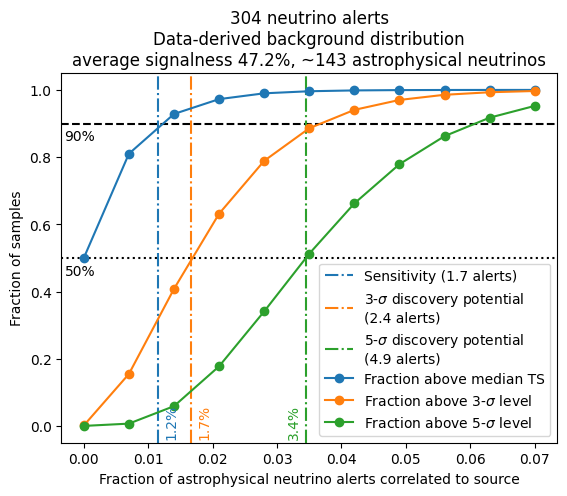

In [17]:
plt.axhline(0.5, color="black", linestyle="dotted")
plt.axhline(0.9, color="black", linestyle="dashed")

plt.axvline(
    x1,
    linestyle="dashdot",
    label="Sensitivity\n(1.9 alerts)"
)
plt.axvline(
    x2,
    linestyle="dashdot",
    color="tab:orange",
    label=r"3-$\sigma$ discovery potential"
    "\n(3.5 alerts)"
)

plt.title(
    f"{n_events} neutrino alerts\n"
    "Data-derived background distribution\n"
    f"average signalness {round(100*avg_signalness,1)}%, "
    f"~{round(n_events*avg_signalness)} astrophysical neutrinos"
)
plt.plot(fracs, sens, marker='o', label="Fraction above median TS")
plt.plot(fracs, sig3, marker='o', label=r"Fraction above 3-$\sigma$ level")
plt.ylabel("Fraction of samples")
plt.xlabel("Fraction of astrophysical neutrino alerts correlated to source")

plt.legend()

# plt.text(0.04, 0.55, "IceCube Preliminary", fontsize="x-large", color="red")

plt.text(x1 + 0.001, -0.03, f"{x1*100:.1f}%", color="tab:blue", rotation=90)
plt.text(x2 + 0.001, -0.03, f"{x2*100:.1f}%", color="tab:orange", rotation=90)
plt.text(x3 - 0.003, -0.03, f"{x3*100:.1f}%", color="tab:green", rotation=90)

plt.text(0.097, 0.91, "90%", color="black")
plt.text(0.097, 0.51, "50%", color="black")

plt.savefig("flaires_sensitivity_5sigma_update_signalness", bbox_inches="tight", dpi=200)
plt.savefig("flaires_sensitivity_5sigma_update_signalness.pdf", bbox_inches="tight", dpi=200)

In [10]:
0.453*298

134.994

In [11]:
import scipy
from scipy.stats import norm, chi2
import numpy as np
import matplotlib.pyplot as plt

class GammaDistribution:
    '''
    This class receives the background TS distribution and fits it to a gamma distribution.
    The function 'calculate_discovery_potential' calculates the value of TS needed to get the discovery potential
    '''

    def __init__(self, data):

        # prepare the data
        default_loc = min(data) - 1.
        data = np.array(data)
        cut = min(data)
        mask = data > cut

        print(cut, data)

        self.frac_under = np.sum(~mask)/float(len(mask))
        N_left = np.sum(~mask)
        print(N_left)

        # define initial guess parameters and bounds for minimization
        p_start = [9., 0., 0.5]
        p_bounds = [(0, None),
                    (0., 0.),
                    (1e-5, 1e5)
                    ]

        # define likelihood function to minimize to obtain the parameters that 
        # better match the data
        def func(p):
            dist = scipy.stats.gamma(p[0], loc=p[1], scale=p[2])
            loglh = dist.logpdf(data).sum()
            loglh += N_left * dist.cdf(cut)
            return -loglh

        # minimize 
        self.res = scipy.optimize.minimize(func, x0=p_start, bounds=p_bounds)
        print(self.res)
        # define gamma distribution that represents the background TS distribution
        self.dist = scipy.stats.gamma(self.res["x"][0], loc=self.res["x"][1], scale=self.res["x"][2])

    def calculate_discovery_potential(self, sigma=5.):
        threshold = (norm.cdf(sigma) - self.frac_under)/(1 - self.frac_under)
        return self.dist.ppf(threshold)

In [12]:
"""
for key, val in all_res[0].items():
    val = np.sort(np.array(val))
    sens_threshold[key] = np.median(val)
    gd = GammaDistribution(val[val!=0.])
    disc_3_threshold[key] = gd.calculate_discovery_potential(3.)
    disc_5_threshold[key] = gd.calculate_discovery_potential(5.)

plot_ts(
    val,
    sens_threshold[key],
    disc_3_threshold[key],
    disc_5_threshold[key],
    filename="attempt_plot.png"
)

cut = min(val)
mask = val > cut
N_left = np.sum(~mask)

p_start = [2.]

def func(p):
    dist = chi2(p[0])
    loglh = dist.logpdf(val).sum()
    loglh += N_left * dist.cdf(cut)
    return -loglh

res = scipy.optimize.minimize(func, x0=p_start)

print(res)

data = np.array(val)
x_range = np.logspace(np.log10(min(data[data>0.])), np.log10(max(data)), 100)
plt.plot(x_range, gd.dist.pdf(x_range))
plt.plot(x_range, chi2.pdf(x_range, res["x"][0]))
plt.ylabel("Density")
plt.title("63 accretion flares from van Velzen, Stein et al.")

#plt.savefig("Sjoert_scrambles", bbox_inches="tight", dpi=200)
"""

'\nfor key, val in all_res[0].items():\n    val = np.sort(np.array(val))\n    sens_threshold[key] = np.median(val)\n    gd = GammaDistribution(val[val>1.])\n    disc_3_threshold[key] = gd.calculate_discovery_potential(3.)\n    disc_5_threshold[key] = gd.calculate_discovery_potential(5.)\n\nplot_ts(\n    val,\n    sens_threshold[key],\n    disc_3_threshold[key],\n    disc_5_threshold[key],\n    filename="attempt_plot.png"\n)\n\ncut = min(val)\nmask = val > cut\nN_left = np.sum(~mask)\n\np_start = [2.]\n\ndef func(p):\n    dist = chi2(p[0])\n    loglh = dist.logpdf(val).sum()\n    loglh += N_left * dist.cdf(cut)\n    return -loglh\n\n#res = scipy.optimize.minimize(func, x0=p_start)\n\n#print(res)\n\ndata = np.array(val)\nx_range = np.logspace(np.log10(min(data[data>0.])), np.log10(max(data)), 100)\nplt.plot(x_range, gd.dist.pdf(x_range))\n#plt.plot(x_range, chi2.pdf(x_range, res["x"][0]))\nplt.ylabel("Density")\nplt.title("63 accretion flares from van Velzen, Stein et al.")\n\n#plt.savef

In [13]:
all_res = sjoert_accretion_flares_analysis.load_results(
    filename="../../../../alertstack_results/sjoert_n10000000_f0.25_s15_update_signalness.pkl"
)
sens_threshold = dict()
disc_3_threshold = dict()
disc_5_threshold = dict()
for key, val in all_res[0.].items():
    print(key, np.array(val))
    sens_threshold[key] = np.median(val)
    print(sens_threshold[key])
    prob_3s = 1.35e-3
    prob_5s = 2.87e-7
    decreasing_vals = np.flip(np.sort(val))
    done_3s = False
    done_5s = False
    if len(val) <= int(1./prob_3s):
        print("Not enough scrambles for evaluating a 3 and 5 sigma level")
        disc_3_threshold[key] = decreasing_vals[0]
        disc_5_threshold[key] = decreasing_vals[0]
        #done_3s = True
        #done_5s = True
    if len(val) <= int(1./prob_5s):
        print("Not enough scrambles for evaluating a 5 sigma level")
        disc_5_threshold[key] = decreasing_vals[0]
        #done_5s = True

    for i, v in enumerate(decreasing_vals):
        prob = (i + 1) / len(val)
        if prob >= prob_3s and not done_3s:
            disc_3_threshold[key] = v
            done_3s = True
        if prob >= prob_5s and not done_5s:
            disc_5_threshold[key] = v
            done_5s = True

print(sens_threshold, disc_3_threshold, disc_5_threshold)

strength_flux_weight [0. 0. 0. ... 0. 0. 0.]
0.0
{'strength_flux_weight': np.float64(0.0)} {'strength_flux_weight': np.float64(9.0351211316573)} {'strength_flux_weight': np.float64(20.155792084050354)}


[  28.91003936   28.91003936   45.49959964   45.49959964   60.81478621
   60.81478621   64.68325668   64.68325668   75.02722848   75.02722848
  116.66149559  116.66149559  117.57151069  117.57151069  130.15270445
  130.15270445  149.1964909   149.1964909   204.18629065  204.18629065
  246.56527619  246.56527619  268.69014118  268.69014118  384.79190235
  384.79190235  388.41867543  388.41867543  463.80593224  463.80593224
  476.68995998  476.68995998  477.71379     477.71379     479.31136049
  479.31136049  571.00734485  571.00734485  597.02113534  597.02113534
  628.46536111  628.46536111  633.61821969  633.61821969  643.14003957
  643.14003957  651.63017782  651.63017782  676.36248561  676.36248561
  697.75424548  697.75424548  738.44803158  738.44803158  744.86721547
  744.86721547  748.64027896  748.64027896  822.6787098   822.6787098
  863.72771421  863.72771421  873.4539214   873.4539214   920.49745869
  920.49745869  948.23226398  948.23226398  977.41325612  977.41325612
  983.6

/home/gsommani/alertstack3.12/lib/python3.12/site-packages/scipy/optimize/_linesearch.py:161: RuntimeWarning: invalid value encountered in scalar divide
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/home/gsommani/alertstack3.12/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:574: RuntimeWarning: invalid value encountered in subtract
  dx = ((x0 + h) - x0)
/home/gsommani/alertstack3.12/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:685: RuntimeWarning: invalid value encountered in scalar subtract
  dx = [(x0[i] + h[i]) - x0[i] for i in range(n)]
/home/gsommani/alertstack3.12/lib/python3.12/site-packages/scipy/optimize/_linesearch.py:395: RuntimeWarning: invalid value encountered in scalar divide
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/home/gsommani/alertstack3.12/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1474: RuntimeWarning: invalid value encountered in scalar multiply
  if (alpha_k*vecnorm(pk) <= xrtol*(xrtol + vecnorm(xk))):


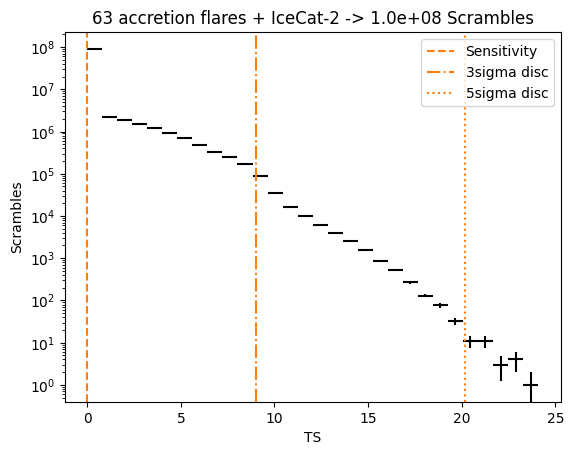

In [14]:
for key, val in all_res[0].items():
    val = np.sort(np.array(val)) * 1e3
    sens_threshold[key] = np.median(val)
    print(val[val>0.])
    gd = GammaDistribution(val[:-10][val[:-10]>0.])
    disc_3_threshold[key] = gd.calculate_discovery_potential(3.)
    disc_5_threshold[key] = gd.calculate_discovery_potential(5.)

plot_ts(
    val,
    sens_threshold[key],
    disc_3_threshold[key],
    disc_5_threshold[key],
    filename="attempt_plot.png"
)

cut = min(val)
mask = val > cut
N_left = np.sum(~mask)

p_start = [2.]

def func(p):
    dist = chi2(p[0])
    loglh = dist.logpdf(val).sum()
    loglh += N_left * dist.cdf(cut)
    return -loglh

res = scipy.optimize.minimize(func, x0=p_start)

print(res)

data = np.array(val)
x_range = np.logspace(np.log10(min(data[data>0.])), np.log10(max(data)), 100)
#plt.plot(x_range, gd.dist.pdf(x_range))
#plt.plot(x_range, chi2.pdf(x_range, res["x"][0]))
#plt.ylim(0.01, 1e8)
plt.ylabel("Scrambles")
#plt.title(f"63 accretion flares from van Velzen, Stein et al. + IceCat-2 -> {len(val):.1e} Scrambles")
plt.title(f"63 accretion flares + IceCat-2 -> {len(val):.1e} Scrambles")
#plt.xscale('linear')
plt.savefig("sjoert_scrambles_update_signalness", bbox_inches="tight", dpi=200)

In [15]:
len(data)

100000000

In [16]:
levels = [
    ("Background Median", sens_threshold),
    ("3 Sigma Discovery Potential", disc_3_threshold),
    ("5 Sigma Discovery Potential", disc_5_threshold)
]

print(levels)

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in all_res.items():
    print("\nFraction of neutrino alerts correlated to source: {0} \n".format(step))

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val) * 1e3

        for name, thresh in levels:
            print(thresh[key])
            print("Fraction above {0}: {1}".format(
                name, np.sum(val > thresh[key])/float(len(val))))
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]
sig3 = [list(above.values())[i][1] for i in range(len(fracs))]
sig5 = [list(above.values())[i][2] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')
f2 = interpolate.interp1d(fracs, sig3, kind='cubic')
f3 = interpolate.interp1d(fracs, sig5, kind='cubic')
\
print(f"\n\n\n*\t*\t*\t*\t*\t*\t*\n\nsens: {sens}\nsig3: {sig3}\nsig5: {sig5}\n\n*\t*\t*\t*\t*\t*\t*\n\n\n")

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in sjoert_accretion_flares_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0, 0.15, xtol=1e-6)
x2 = bisect(lambda x: f2(x)-0.5, 0, 0.15, xtol=1e-6)
x3 = bisect(lambda x: f3(x)-0.5, 0, 0.15, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("3 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x2,(x2*avg_signalness)*n_events,n_events,(x2*avg_signalness)))
print("5 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x3,(x3*avg_signalness)*n_events,n_events,(x3*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")

[('Background Median', {'strength_flux_weight': np.float64(0.0)}), ('3 Sigma Discovery Potential', {'strength_flux_weight': np.float64(9.0351211316573)}), ('5 Sigma Discovery Potential', {'strength_flux_weight': np.float64(20.155792084050354)})]

Fraction of neutrino alerts correlated to source: 0.0 

0.0
Fraction above Background Median: 0.12443261
9.0351211316573
Fraction above 3 Sigma Discovery Potential: 0.00134997
20.155792084050354
Fraction above 5 Sigma Discovery Potential: 2.7e-07

Fraction of neutrino alerts correlated to source: 0.016666666666666666 

0.0
Fraction above Background Median: 0.4677467
9.0351211316573
Fraction above 3 Sigma Discovery Potential: 0.2211193
20.155792084050354
Fraction above 5 Sigma Discovery Potential: 0.0126204

Fraction of neutrino alerts correlated to source: 0.03333333333333333 

0.0
Fraction above Background Median: 0.6761641
9.0351211316573
Fraction above 3 Sigma Discovery Potential: 0.4161356
20.155792084050354
Fraction above 5 Sigma Discover

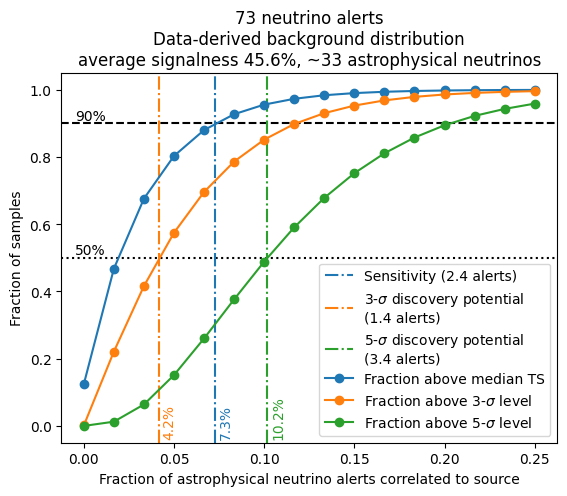

In [17]:
plt.axhline(0.5, color="black", linestyle="dotted")
plt.axhline(0.9, color="black", linestyle="dashed")

plt.axvline(
    x1,
    linestyle="dashdot",
    label="Sensitivity\n(2.2 alerts)"
)
plt.axvline(
    x2,
    linestyle="dashdot",
    color="tab:orange",
    label=r"3-$\sigma$"
    " discovery potential\n(1.7 alerts)"
)

plt.title(
    f"{n_events} neutrino alerts\n"
    "Data-derived background distribution\n"
    f"average signalness {round(100*avg_signalness,1)}%, "
    f"~{round(n_events*avg_signalness)} astrophysical neutrinos"
)
plt.plot(fracs, sens, marker='o', label="Fraction above median TS")
plt.plot(fracs, sig3, marker='o', label=r"Fraction above 3-$\sigma$ level")
plt.ylabel("Fraction of samples")
plt.xlabel("Fraction of astrophysical neutrino alerts correlated to source")

plt.legend()

# plt.text(0.14, 0.53, "IceCube Preliminary", fontsize="x-large", color="red")

plt.text(0.065, 0.94, "7.0%", color="tab:blue", rotation=90)
plt.text(0.048, 0.94, "5.3%", color="tab:orange", rotation=90)

plt.text(-0.005, 0.91, "90%", color="black")
plt.text(-0.005, 0.51, "50%", color="black")

plt.savefig("sjoert_sensitivity_5sigma_update_signalness", bbox_inches="tight", dpi=200)
plt.savefig("sjoert_sensitivity_5sigma_update_signalness.pdf", bbox_inches="tight", dpi=200)

In [ ]:
0.438*73